<h1> FEMM (Finite Element Method Magnetics) </h1>

In [3]:
import torch
import numpy as np
import time
import meshio

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Выбрано: {device}")

start = time.time()

#загрузка сетки
mesh = meshio.read("dipole2d.msh")

#координаты узлов
X_y = mesh.points[:, :2]

Выбрано: cuda



In [ ]:
print(X_y)

In [6]:
all_triangles = []
all_triangle_tags = []
all_lines = []
all_line_tags = []

#теги 
physical_data = mesh.cell_data.get("gmsh:physical", [])

for i, cell_block in enumerate(mesh.cells):
    if cell_block.type == "triangle":
        all_triangles.append(cell_block.data)
        all_triangle_tags.append(physical_data[i])
            
    elif cell_block.type == "line":
        all_lines.append(cell_block.data)
        all_line_tags.append(physical_data[i])

#объединение в один массив
triangles = np.concatenate(all_triangles, axis=0)
triangle_tags = np.concatenate(all_triangle_tags, axis=0)
lines = np.concatenate(all_lines, axis=0)
line_tags = np.concatenate(all_line_tags, axis=0)

In [ ]:
print(triangles, triangle_tags)

In [ ]:
print(lines, line_tags)

<h2> Mesh Visualization </h2>

In [9]:
import matplotlib.pyplot as plt
import matplotlib.tri as tri

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


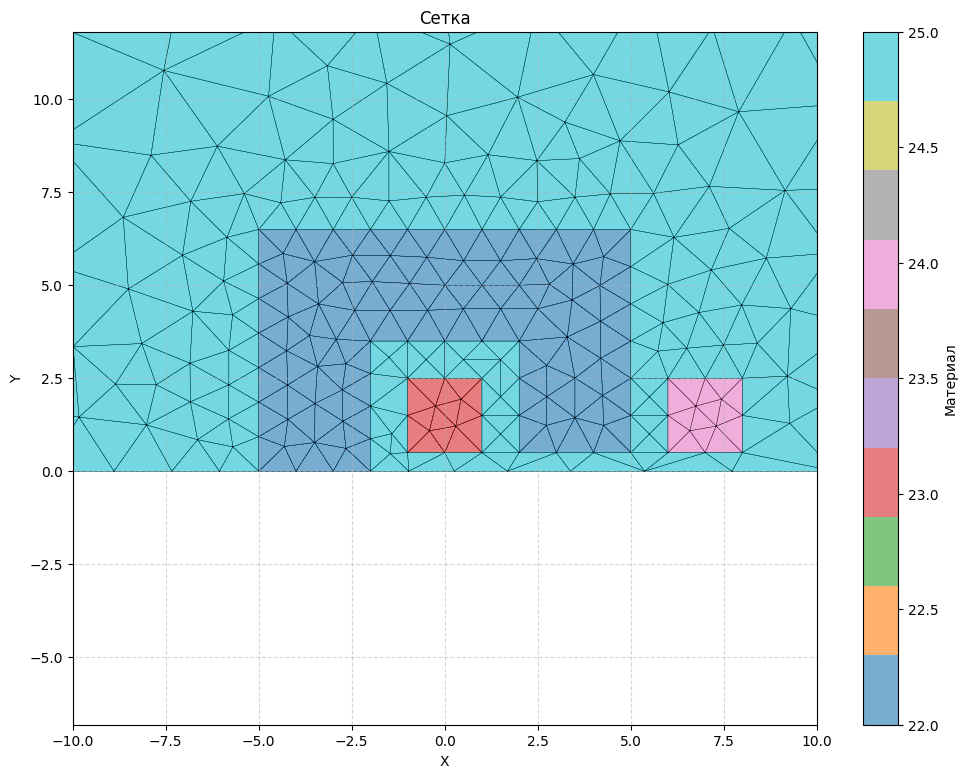

In [10]:
triang = tri.Triangulation(X_y[:, 0], X_y[:, 1], triangles)

plt.figure(figsize=(12, 9))

tpc = plt.tripcolor(triang, facecolors=triangle_tags, cmap='tab10', alpha=0.6)

plt.triplot(triang, color='black', lw=0.3)

plt.colorbar(tpc, label="Материал")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Сетка")

plt.axis('equal') 

plt.xlim(-10, 10)
plt.ylim(-5, 10)

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [11]:
# mu_elem_np = np.ones(len(triangles))
# mu_elem_np[triangle_tags == 22] = 1000.0

mu0 = 4 * np.pi * 1e-7
mu_steel = 1000.0 * mu0

mu_elem_np = np.ones(len(triangles)) * mu0
mu_elem_np[triangle_tags == 22] = mu_steel  # 22 — сталь

J_elem_np = np.zeros(len(triangles))
J_elem_np[triangle_tags == 23] = 1.0
J_elem_np[triangle_tags == 24] = -1.0 

In [ ]:
print(mu_elem_np)
print(J_elem_np)

In [13]:
nodes = torch.tensor(X_y, dtype=torch.float32, device=device)
elements = torch.tensor(triangles, dtype=torch.long, device=device)
mu_elem = torch.tensor(mu_elem_np, dtype=torch.float32, device=device)
J_elem = torch.tensor(J_elem_np, dtype=torch.float32, device=device)

num_nodes = nodes.shape[0]

In [14]:
import scipy.sparse as sp
import scipy.sparse.linalg as spla

In [15]:
#локальные матрицы
p = nodes[elements]
p1, p2, p3 = p[:, 0], p[:, 1], p[:, 2]
    
area = 0.5 * torch.abs((p2[:, 0] - p1[:, 0]) * (p3[:, 1] - p1[:, 1]) - 
                       (p3[:, 0] - p1[:, 0]) * (p2[:, 1] - p1[:, 1]))
    
alpha_1 = torch.stack([p2[:, 1] - p3[:, 1], 
                       p3[:, 1] - p1[:, 1], 
                       p1[:, 1] - p2[:, 1]], dim=1)
    
alpha_2 = torch.stack([p3[:, 0] - p2[:, 0], 
                       p1[:, 0] - p3[:, 0], 
                       p2[:, 0] - p1[:, 0]], dim=1)
     
G_local = (1.0 / (4.0 * area * mu_elem))[:, None, None] * (alpha_1[:, :, None] * alpha_1[:, None, :] + 
                                                 alpha_2[:, :, None] * alpha_2[:, None, :])
    

#вектор правой части
F_local = (J_elem * area / 3.0)[:, None].expand(-1, 3)

#сборка глобальной матрицы
rows_np = elements[:, :, None].expand(-1, 3, 3).reshape(-1).cpu().numpy()
cols_np = elements[:, None, :].expand(-1, 3, 3).reshape(-1).cpu().numpy()
vals_np = G_local.reshape(-1).cpu().numpy()

G_sparse = sp.coo_matrix((vals_np, (rows_np, cols_np)), shape=(num_nodes, num_nodes)).tolil()

F = torch.zeros(num_nodes, device=device)
F.index_add_(0, elements.reshape(-1), F_local.reshape(-1))
F_np = F.cpu().numpy()

F = torch.zeros(num_nodes, device=device)
F.index_add_(0, elements.reshape(-1), F_local.reshape(-1))
F_np = F.cpu().numpy()

In [16]:
dirichlet_lines = lines[line_tags == 27]
dirichlet_idx = np.unique(dirichlet_lines)

G_sparse[dirichlet_idx, :] = 0.0
G_sparse[dirichlet_idx, dirichlet_idx] = 1.0
G_sparse = G_sparse.tocsr()

F_np[dirichlet_idx] = 0.0

In [17]:
u_fem_np = spla.spsolve(G_sparse, F_np)
u_fem = torch.tensor(u_fem_np, dtype=torch.float32, device=device)

output_filename = "fem_results.npz"

np.savez(
    output_filename,
    nodes=X_y,
    triangles=triangles,
    u_fem=u_fem_np,
    triangle_tags=triangle_tags
)

end = time.time()

print(f"Время решения:       {end - start:.4f} сек")
print(f"Количество узлов:    {num_nodes}")
print(f"Количество элементов: {elements.shape[0]}")


Время решения:       2.8363 сек
Количество узлов:    385
Количество элементов: 719


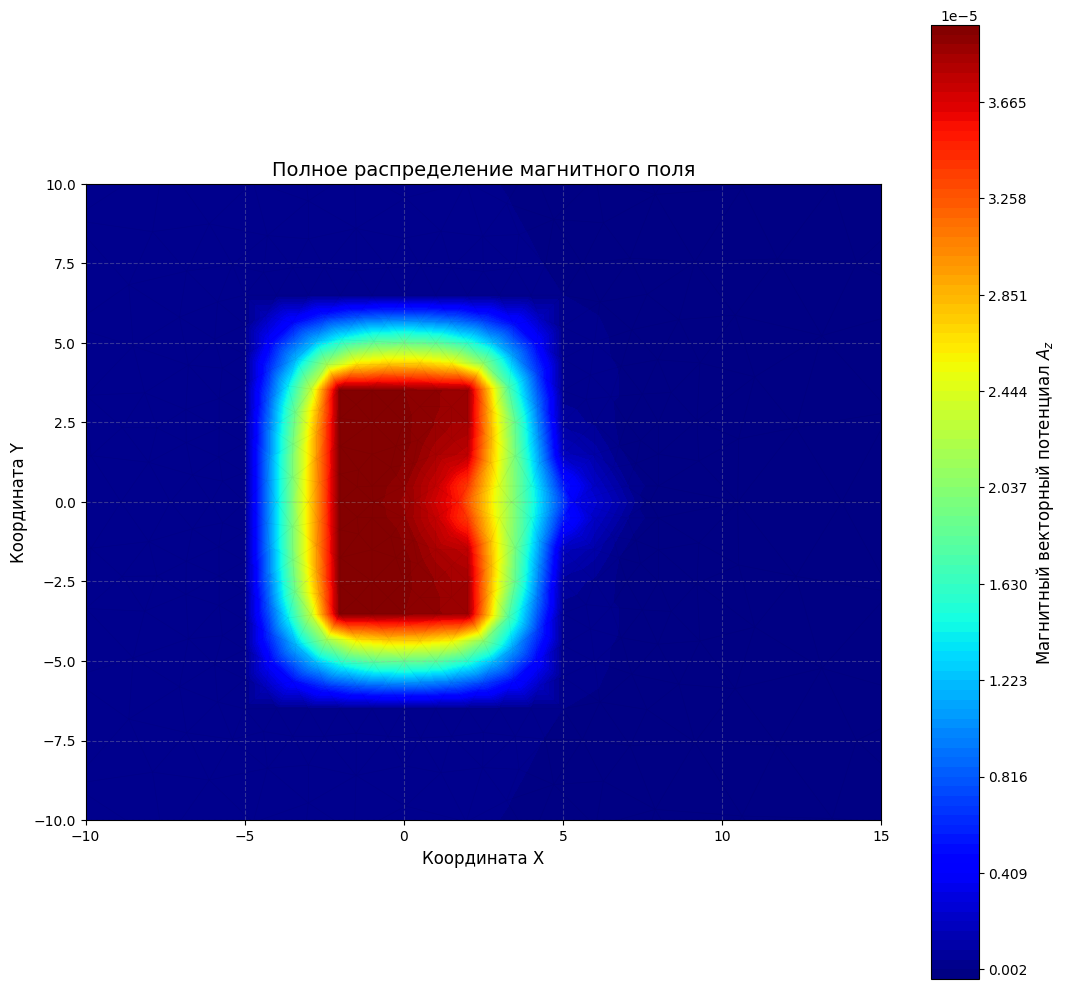

In [18]:
#объект триангуляции matplotlib

triangulation_top = tri.Triangulation(X_y[:, 0], X_y[:, 1], triangles)
triangulation_bottom = tri.Triangulation(X_y[:, 0], -X_y[:, 1], triangles)

plt.figure(figsize=(11, 10))
ax = plt.gca()
ax.set_aspect('equal')

vmin = u_fem_np.min()
vmax = u_fem_np.max()
levels = np.linspace(vmin, vmax, 100)

contour_top = ax.tricontourf(triangulation_top, u_fem_np, levels=levels, cmap='jet')
contour_bottom = ax.tricontourf(triangulation_bottom, u_fem_np, levels=levels, cmap='jet')

ax.triplot(triangulation_top, color='black', alpha=0.05, linewidth=0.5)
ax.triplot(triangulation_bottom, color='black', alpha=0.05, linewidth=0.5)

cbar = plt.colorbar(contour_top)
cbar.set_label('Магнитный векторный потенциал $A_z$', fontsize=12)

ax.set_xlim(-10, 15)
ax.set_ylim(-10, 10)

# ax.set_xlim(-55, 55)
# ax.set_ylim(-55, 55)

plt.title('Полное распределение магнитного поля', fontsize=14)
plt.xlabel('Координата X', fontsize=12)
plt.ylabel('Координата Y', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()

plt.show()

<h1> Переход от найденного скалярного потенациала <i>A</i><sub>z</sub> к вектору магнитной индукции <i>B</i> </h1>

In [19]:
#интерполяторы (значение потенциала в произвольной точке)
interp_top = tri.LinearTriInterpolator(triangulation_top, u_fem_np)
interp_bottom = tri.LinearTriInterpolator(triangulation_bottom, u_fem_np)

X, Y = np.meshgrid(np.linspace(-7, 9, 40), np.linspace(-8, 8, 40))

U = np.zeros_like(X)
V = np.zeros_like(Y)

#отбор внутренних точек
mask_top = (Y >= 0) & (triangulation_top.get_trifinder()(X, Y) != -1)
mask_bottom = (Y < 0) & (triangulation_bottom.get_trifinder()(X, Y) != -1)

<h3> Расчет компонент магнитной индукции <i>B</i> </h3>

In [20]:
dAdx_t, dAdy_t = interp_top.gradient(X[mask_top], Y[mask_top])
U[mask_top] = dAdy_t
V[mask_top] = -dAdx_t

dAdx_b, dAdy_b = interp_bottom.gradient(X[mask_bottom], Y[mask_bottom])
U[mask_bottom] = dAdy_b
V[mask_bottom] = -dAdx_b

B_norm_grid = np.sqrt(U**2 + V**2)
mask_total = mask_top | mask_bottom

In [21]:
dAdx_n, dAdy_n = interp_top.gradient(X_y[:, 0], X_y[:, 1])
B_norm_nodes = np.sqrt(dAdy_n**2 + dAdx_n**2)

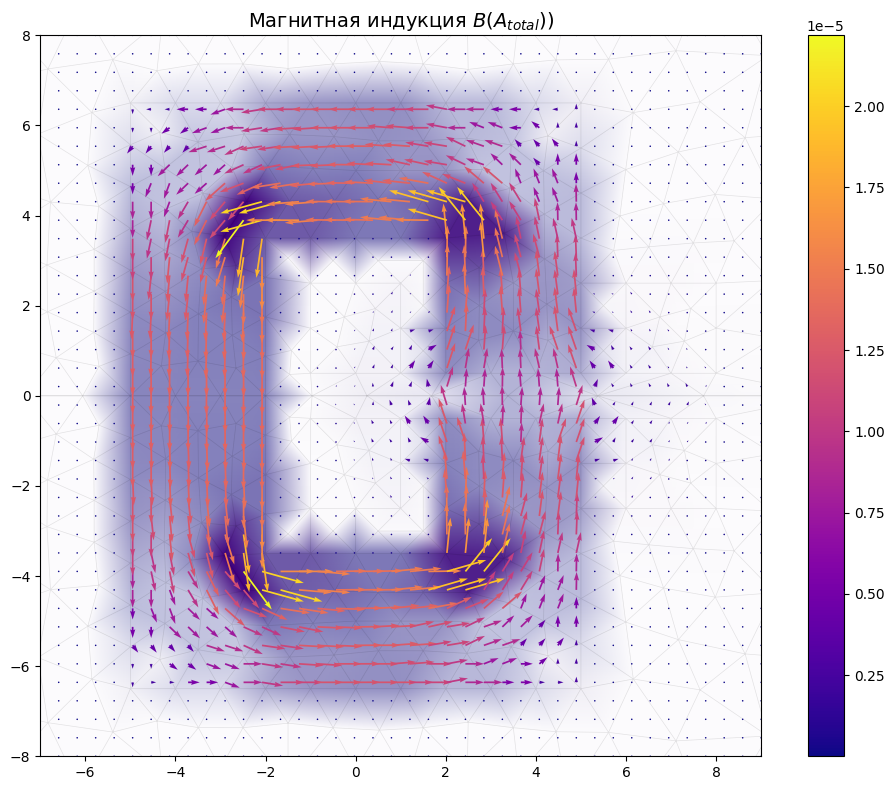

In [27]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.set_aspect('equal')
ax.set_xlim(-7, 9)
ax.set_ylim(-8, 8)
ax.set_title('Магнитная индукция $B(A_{total})$)', fontsize=14)

ax.tripcolor(triangulation_top, B_norm_nodes, shading='gouraud', cmap='Purples')
ax.tripcolor(triangulation_bottom, B_norm_nodes, shading='gouraud', cmap='Purples')

ax.triplot(triangulation_top, color='black', alpha=0.1, linewidth=0.5)
ax.triplot(triangulation_bottom, color='black', alpha=0.1, linewidth=0.5)

bar = ax.quiver(X[mask_total], Y[mask_total], U[mask_total], V[mask_total], B_norm_grid[mask_total], cmap='plasma')

fig.colorbar(bar, ax=ax)
plt.tight_layout()
plt.show()